# Project Workbook

In [1]:
# Import Pennylane libraries
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers

# Import Tensorflow and Keras
import tensorflow as tf
from tensorflow import keras
from keras.src import activations
from keras.src import initializers
from keras.src import ops
from keras.src.layers.layer import Layer

# Import Matplotlib
import matplotlib.pyplot as plt

# Auxiliary modules
import json
import os
from PIL import Image

# Accelerate with GPU
print("GPUs Available: ", tf.config.list_physical_devices('GPU'))

GPUs Available:  []


## Loading Dataset

In [4]:

# Dataset
SAVE_PATH = "./al5083/"           # Data saving folder (locally)
PREPROCESS = True                           # If False, skip quantum processing and load data from SAVE_PATH
SETSEED = False
if SETSEED:
    np.random.seed(0)           # Seed for NumPy random number generator
    tf.random.set_seed(0)       # Seed for TensorFlow random number generator

# Space and time management
LABEL_LIMIT = 1024                # Mechanism to save time and space by label count
SCALE_FACTOR = 16                 # Downscale factor

# Image size
HEIGHT = 800
WIDTH = 974
LABELS = 6                # Units of dense second layer
LABEL_TITLES = ["good","burn","contamination","lack_fusion", "misalignment", "lack_penetration"]

def load_data(path, subpath, limit=LABEL_LIMIT):
    images, labels, defectives, sources = [], [], [], []
    labelsource = None
    with open(SAVE_PATH + "{0:s}/{0:s}.json".format(subpath), 'r') as json_file:
        labelsource = json.load(json_file) # returns a JSON of source-label pairs
    label_count = [0]*LABELS
    for folder in os.listdir(path + subpath):
        folder_path = os.path.join(path + subpath, folder)
        if(os.path.isdir(folder_path)):
            for img_name in os.listdir(folder_path):
                
                img_path = os.path.join(folder_path, img_name)
                key_name = folder + '/' + img_name
                label = labelsource[key_name]

                # Mechanism to save time and space
                if(label_count[label] >= limit):
                    continue
                if(len(images) >= LABELS*limit):
                    break
                label_count[label] += 1

                # Extract image, with downscaling as mechanism to save space
                image = Image.open(img_path)
                image = image.resize((HEIGHT//SCALE_FACTOR, WIDTH//SCALE_FACTOR), Image.Resampling.LANCZOS)

                # Convert to numpy, and save label
                images.append(np.array(image))
                labels.append(label)
                defectives.append([int(bool(label))])
                sources.append(key_name)
                
                if(len(images)%100==0):
                    print(f"Total images loaded : {len(images)}, Label count : {label_count}", end = '\r')
            # End of image processing
        # Skip non-folders
    # End of folder processing, return normalized numpy array of images, labels array, and sources list. 
    # Add extra dimension for convolution channels
    return np.array(np.array(images)[..., tf.newaxis], requires_grad=False) / 255, np.array(labels), np.array(defectives), sources

train_images, train_labels, train_defective, train_sources = load_data(SAVE_PATH, "train")
print()
test_images, test_labels, train_defective, test_sources = load_data(SAVE_PATH, "test", 128)
print()
RANDOMINDEX = np.random.randint(len(train_images))
print("Size of initial tensor #{3:d}: {0:s}, status: {1:d}, filename: '{2:s}'".format( \
    str(train_images[RANDOMINDEX].shape), train_labels[RANDOMINDEX], train_sources[RANDOMINDEX], RANDOMINDEX))

Total images loaded : 6100, Label count : [1024, 1024, 1024, 980, 1024, 1024]
Total images loaded : 700, Label count : [128, 128, 128, 60, 128, 128]
Size of initial tensor #4568: (60, 50, 1), status: 1, filename: '170906-144958-Al 2mm/frame_00447.png'


## Set Training Settings

In [9]:
# Epochs
n_epochs = 10                   # Number of optimization epochs
n_train = -1                     # Size of the train dataset (-1 for entire)
n_valid = -1                     # Size of the validation dataset (-1 for entire)
n_test = -1                      # Size of the test dataset (-1 for entire)
batch_size = 16                  # Batch size used for training iterations

train_images = train_images[:n_train]
train_labels = train_labels[:n_train]
test_images = test_images[:n_test]
test_labels = test_labels[:n_test]

## Display Data

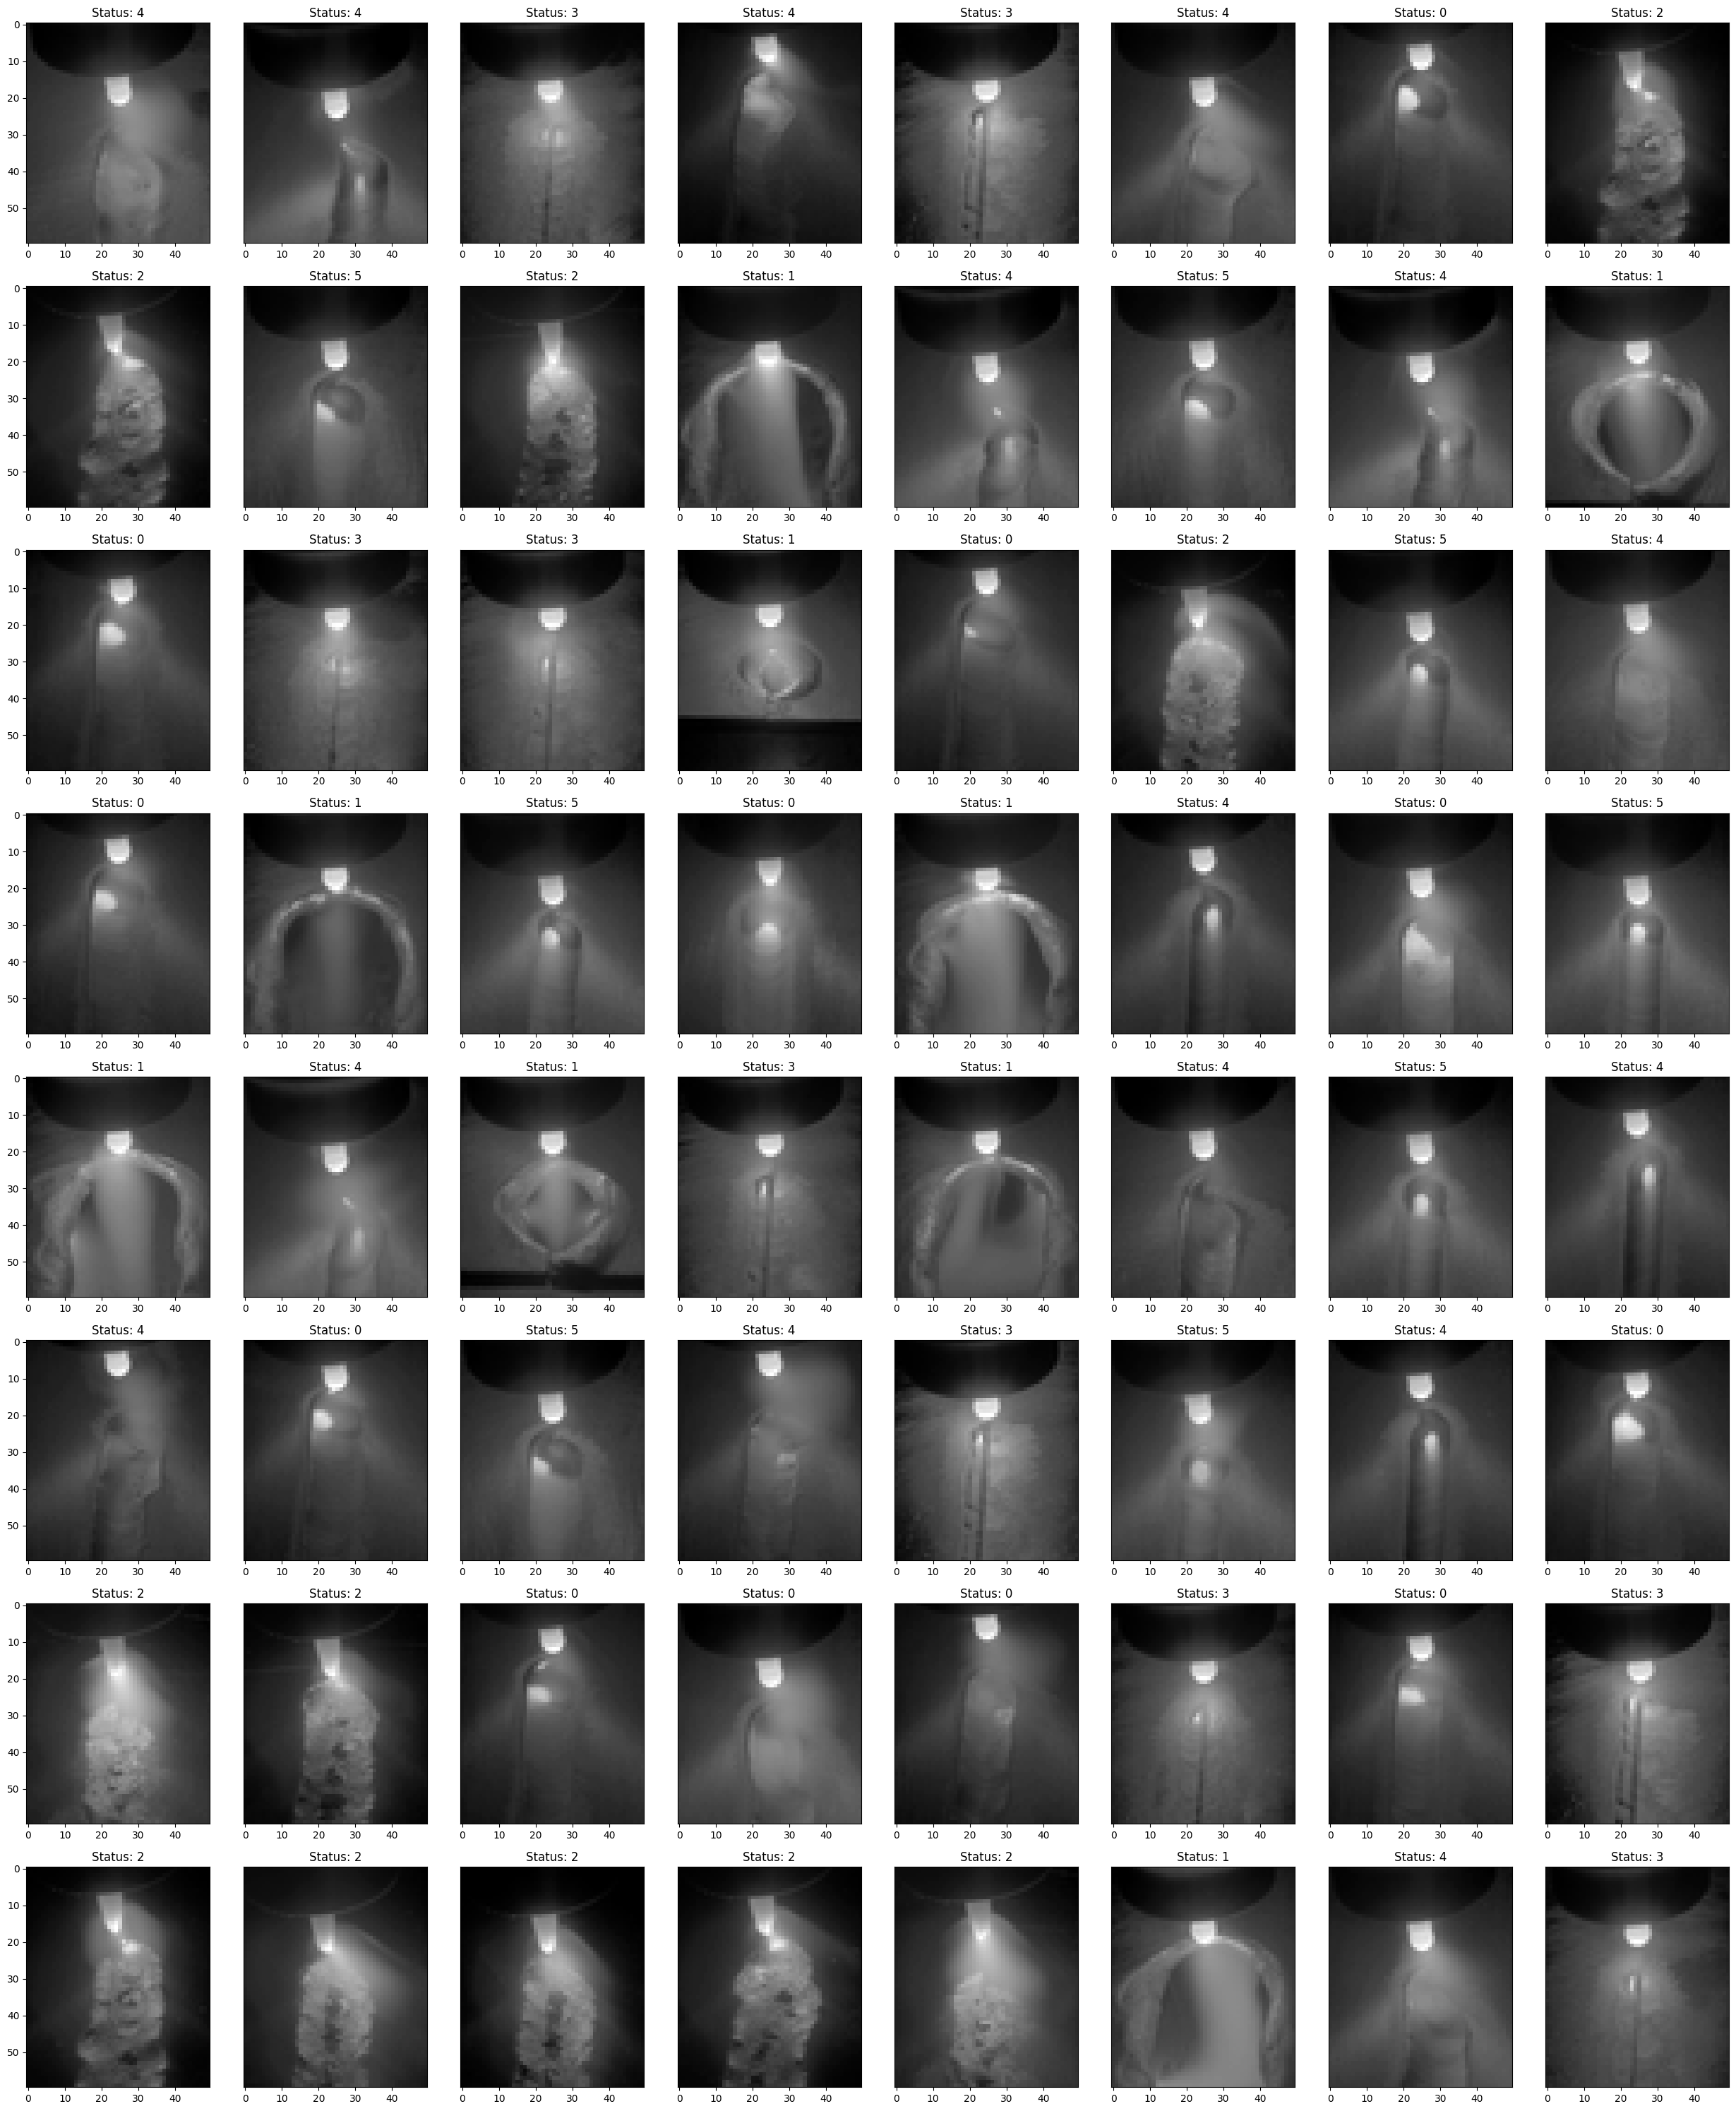

In [6]:
DISPLAYSQRT = 8
fig, axes = plt.subplots(DISPLAYSQRT, DISPLAYSQRT, figsize=(25, 30))
# Column number is the sample used
for i in range(DISPLAYSQRT):
    for j in range(DISPLAYSQRT):
        # Randomize
        RANDOMINDEX = np.random.randint(len(train_images))
        # Plot title
        axes[i, j].set_title("Status: {0:d}".format(train_labels[RANDOMINDEX]))
        if j != 0:
            axes[i, j].yaxis.set_visible(False)
        axes[i, j].imshow(train_images[RANDOMINDEX, :, :, 0], cmap="gray")
plt.tight_layout()
plt.show()

## Models and Hyperparameters

As depicted by the original paper.

In [10]:
seq = keras.models.Sequential([
    keras.layers.Resizing(HEIGHT//2, WIDTH//2),
    keras.layers.Conv2D(16, 5, activation="relu", strides=1),
    keras.layers.MaxPooling2D(pool_size=5, strides=2),
    keras.layers.Conv2D(32, 5, activation="relu", strides=1),
    keras.layers.MaxPooling2D(pool_size=5, strides=2),
    keras.layers.Conv2D(64, 5, activation="relu", strides=1),
    keras.layers.MaxPooling2D(pool_size=5, strides=2),
    keras.layers.Conv2D(128, 5, activation="relu", strides=1),
    keras.layers.MaxPooling2D(pool_size=5, strides=2),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(LABELS, activation="softmax")
])

def cmodel(model):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""

    model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## Classical Training

In [11]:
c_history = cmodel(seq).fit(
    train_images,
    train_labels,
    validation_data=(test_images, test_labels),
    batch_size=batch_size,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/10
384/384 - 586s - 2s/step - accuracy: 0.6281 - loss: 0.8552 - val_accuracy: 0.3982 - val_loss: 4.8123
Epoch 2/10
384/384 - 606s - 2s/step - accuracy: 0.9596 - loss: 0.1130 - val_accuracy: 0.4700 - val_loss: 3.1729
Epoch 3/10
384/384 - 512s - 1s/step - accuracy: 0.9700 - loss: 0.0838 - val_accuracy: 0.3564 - val_loss: 4.7279
Epoch 4/10
384/384 - 558s - 1s/step - accuracy: 0.9826 - loss: 0.0519 - val_accuracy: 0.3721 - val_loss: 4.7729
Epoch 5/10
384/384 - 1703s - 4s/step - accuracy: 0.9810 - loss: 0.0559 - val_accuracy: 0.4922 - val_loss: 4.4770
Epoch 6/10
384/384 - 576s - 1s/step - accuracy: 0.9920 - loss: 0.0232 - val_accuracy: 0.4987 - val_loss: 5.7671
Epoch 7/10
384/384 - 509s - 1s/step - accuracy: 0.9832 - loss: 0.0483 - val_accuracy: 0.4739 - val_loss: 4.8220
Epoch 8/10
384/384 - 531s - 1s/step - accuracy: 0.9940 - loss: 0.0169 - val_accuracy: 0.4739 - val_loss: 5.2318
Epoch 9/10
384/384 - 491s - 1s/step - accuracy: 0.9914 - loss: 0.0270 - val_accuracy: 0.3956 - val_loss

## Displaying the results

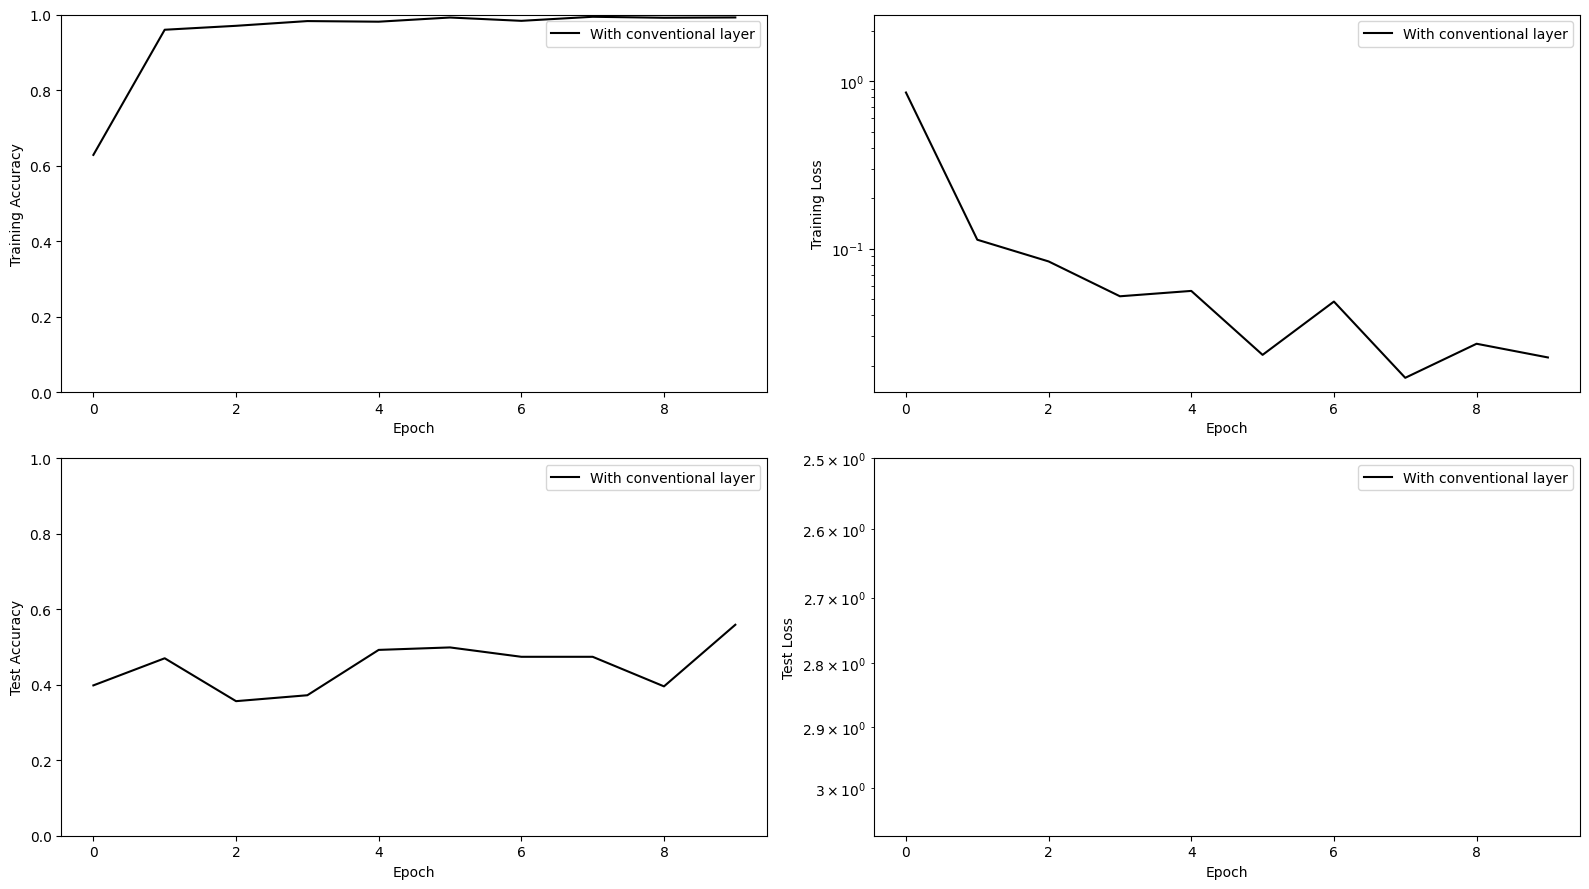

In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 9))

ax1.plot(c_history.history["accuracy"], "-k", label="With conventional layer")
ax1.set_ylabel("Training Accuracy")
ax1.set_ylim([0, 1])
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(c_history.history["loss"], "-k", label="With conventional layer")
ax2.set_yscale("log")
ax2.set_ylabel("Training Loss")
ax2.set_ylim(top=2.5)
ax2.set_xlabel("Epoch")
ax2.legend()

ax3.plot(c_history.history["val_accuracy"], "-k", label="With conventional layer")
ax3.set_ylabel("Test Accuracy")
ax3.set_ylim([0, 1])
ax3.set_xlabel("Epoch")
ax3.legend()

ax4.plot(c_history.history["val_loss"], "-k", label="With conventional layer")
ax4.set_yscale("log")
ax4.set_ylabel("Test Loss")
ax4.set_ylim(top=2.5)
ax4.set_xlabel("Epoch")
ax4.legend()

plt.tight_layout()
plt.show()

## The QNN

[[2.55330562 1.23059269 4.16718222]
 [3.77276346 5.36664276 4.31661223]
 [5.68260688 4.61260559 2.803668  ]]
[[3.34706295 5.11438459 3.50879214]
 [3.27865375 3.17332816 4.44109778]
 [1.58040542 4.03109809 4.84877577]]


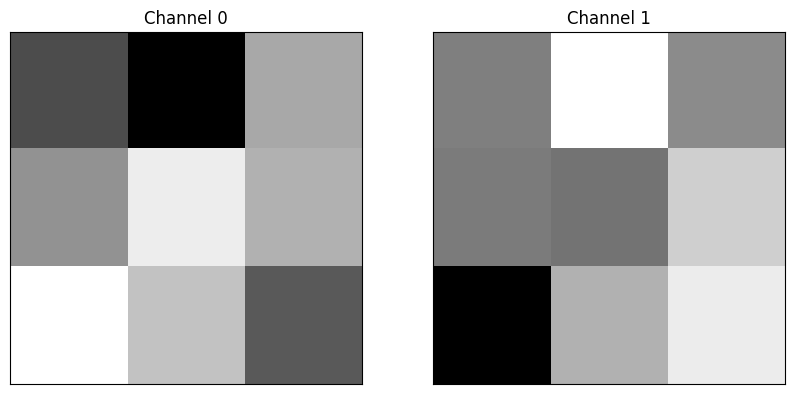

In [24]:
# Define some basic parameters
kernel_size = 3  # Example kernel size
n_channels = 2  # Number of channels (for example, color channels in an image)
HEIGHT, LENGTH = 64, 64  # Image dimensio

@qml.qnode(dev)
def circuit(phi):
    # Encoding of classical input values from kernel
    for wire in range(kernel_size*kernel_size):
        qml.RY(np.pi * phi[wire], wires=wire)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(kernel_size*kernel_size)))

    # Measurement producing classical output values
    return [qml.expval(qml.PauliZ(j)) for j in range(kernel_size*kernel_size)]

def generatefilter(image, j, k):
    """Lists out the neighboring cells useed for this convolution"""
    filter = []
    for j1 in range(0, kernel_size):
        for k1 in range(0, kernel_size):
            filter.append(image[j + j1, k + k1, 0])
    return filter

def quanv(image):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((HEIGHT//kernel_size, LENGTH//kernel_size, kernel_size*kernel_size))

    # Loop over the coordinates of the top-left pixel of squares
    for j in range(0, HEIGHT - kernel_size + 1, kernel_size):
        for k in range(0, LENGTH - kernel_size + 1, kernel_size):
            # Process a squared region of the image with a quantum circuit
            q_results = circuit(generatefilter(image, j, k))
            # Assign expectation values to different channels of the output pixel as pooling layer
            for c in range(kernel_size*kernel_size):
                out[j // kernel_size, k // kernel_size, c] = q_results[c]
    return out

# Quantum circuit as a convolution kernel
dev = qml.device("default.qubit", wires=kernel_size*kernel_size+1)
rand_params = np.random.uniform(high=2 * np.pi, size=(n_channels, kernel_size*kernel_size))
rand_params # A L × K² tensor

fig, axes = plt.subplots(1, n_channels, figsize=(10, 10))
for k in range(n_channels):
    axes[k].set_title("Channel {0:d}".format(k))
    axes[k].xaxis.set_visible(False)
    axes[k].yaxis.set_visible(False)
    print(rand_params[k].reshape([kernel_size,kernel_size]))
    axes[k].imshow(rand_params[k].reshape([kernel_size,kernel_size]), cmap="gray") # Lighter indicate higher value

class Quanv2D(Layer):
    def __init__(self, filters, kernel_size,
        activation=None,
        use_bias=True,
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros"
    ):
        super().__init__()
        self.filters = filters
        self.kernel_size = standardize_tuple(kernel_size, rank, "kernel_size")
        self.activation = activations.get(activation)
        self.kernel_initializer = initializers.get(kernel_initializer)
        self.bias_initializer = initializers.get(bias_initializer)

        if self.filters is not None and self.filters <= 0:
            raise ValueError(
                "Invalid value for argument `filters`. Expected a strictly "
                f"positive value. Received filters={self.filters}."
            )
        if not all(self.kernel_size):
            raise ValueError(
                "The argument `kernel_size` cannot contain 0. Received "
                f"kernel_size={self.kernel_size}."
            )

        self.kernel = self.add_weight(
            name="kernel",
            shape=(self.kernel_size*self.kernel_size, filters),
            initializer=self.kernel_initializer,
            # regularizer=self.kernel_regularizer,
            # constraint=self.kernel_constraint,
            trainable=True,
            dtype=self.dtype,
        )
        if self.use_bias:
            self.bias = self.add_weight(
                name="bias",
                shape=(self.filters,),
                initializer=self.bias_initializer,
                trainable=True,
                dtype=self.dtype,
            )
        else:
            self.bias = None

    def call(self, inputs):
        outputs = quanv(inputs)
        if self.use_bias:
            if self.data_format == "channels_last":
                bias_shape = (1,) * (self.rank + 1) + (self.filters,)
            else:
                bias_shape = (1, self.filters) + (1,) * self.rank
            bias = ops.reshape(self.bias, bias_shape)
            outputs += bias

        if self.activation is not None:
            return self.activation(outputs)
        return outputs